In [1]:
import sys
import os
import json
import torch


import numpy as np
import matplotlib.pyplot as plt
import pandas

from matplotlib import rcParams
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage,AnchoredOffsetbox
import glob
from sklearn.metrics import mean_squared_error
from torchmetrics.image import StructuralSimilarityIndexMeasure
import torchvision

from numpy import dot
from numpy.linalg import norm


rcParams['font.family'] = 'Times'
rcParams['font.sans-serif'] = ['Tahoma']
plt.rcParams.update({'font.size': 18})

ssim = StructuralSimilarityIndexMeasure()

from scipy.interpolate import interp1d


In [2]:
for name in glob.glob('results/*'):
    print(name)


results/b84477c5
results/0a6dbd3a
results/06c1ee2d
results/f6a42406
results/e03a8047
results/df12942b
results/3a865e97
results/8c3f0b86
results/e3bfbedf
results/a3d6d65e
results/4e4150e1
results/27a91774
results/bdc06d34


results/b84477c5
Angle 0° - Cosine: 0.07812172178582041, MSE: 0.030009191810069513
Angle 10° - Cosine: 0.28917768652660647, MSE: 0.00042758334556203877
Angle 20° - Cosine: 0.17733854947203018, MSE: 0.012786611406079139


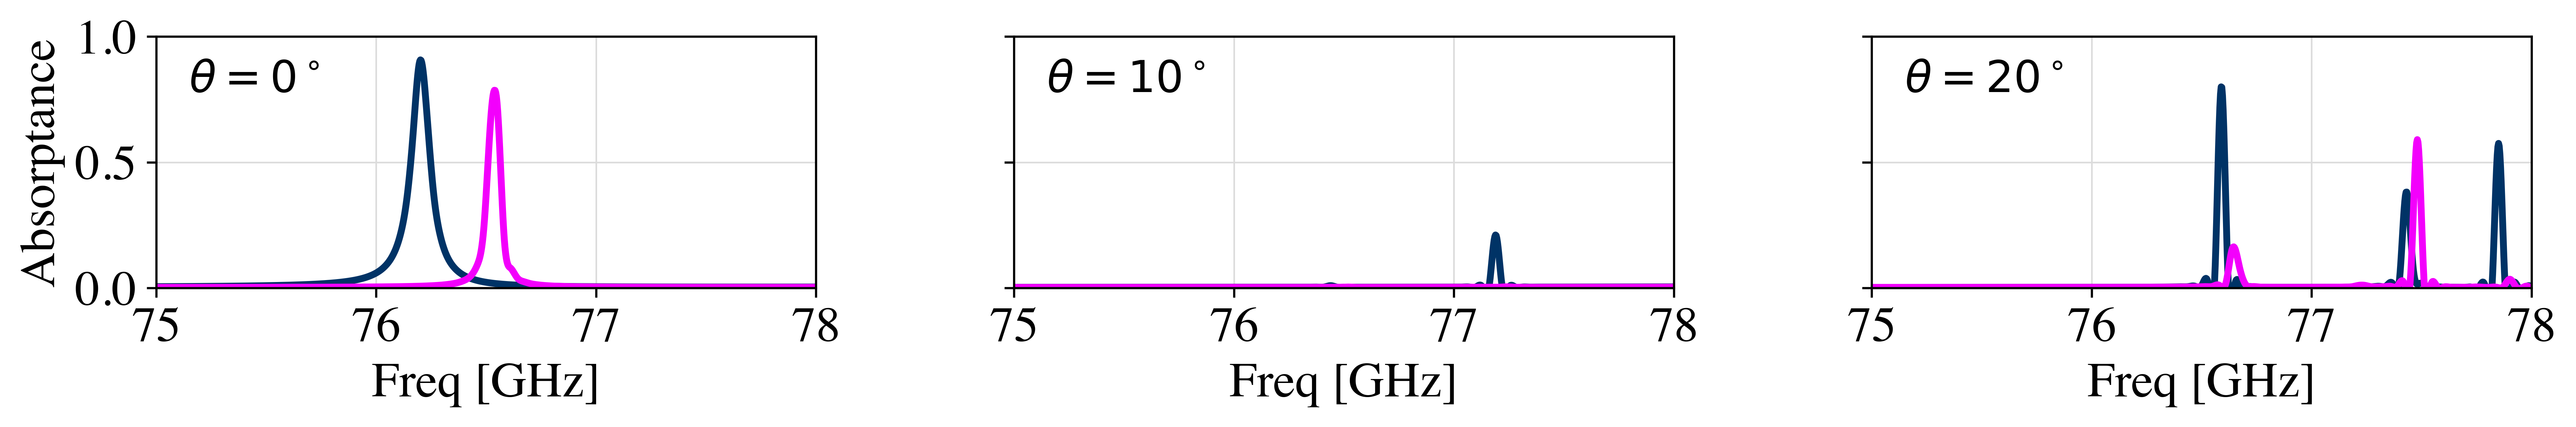

results/0a6dbd3a
Angle 0° - Cosine: 0.6900536073936748, MSE: 0.006465191008509451
Angle 10° - Cosine: 0.3461600720247678, MSE: 0.00010093822727771855
Angle 20° - Cosine: 0.04443165013068099, MSE: 0.010173521102221816


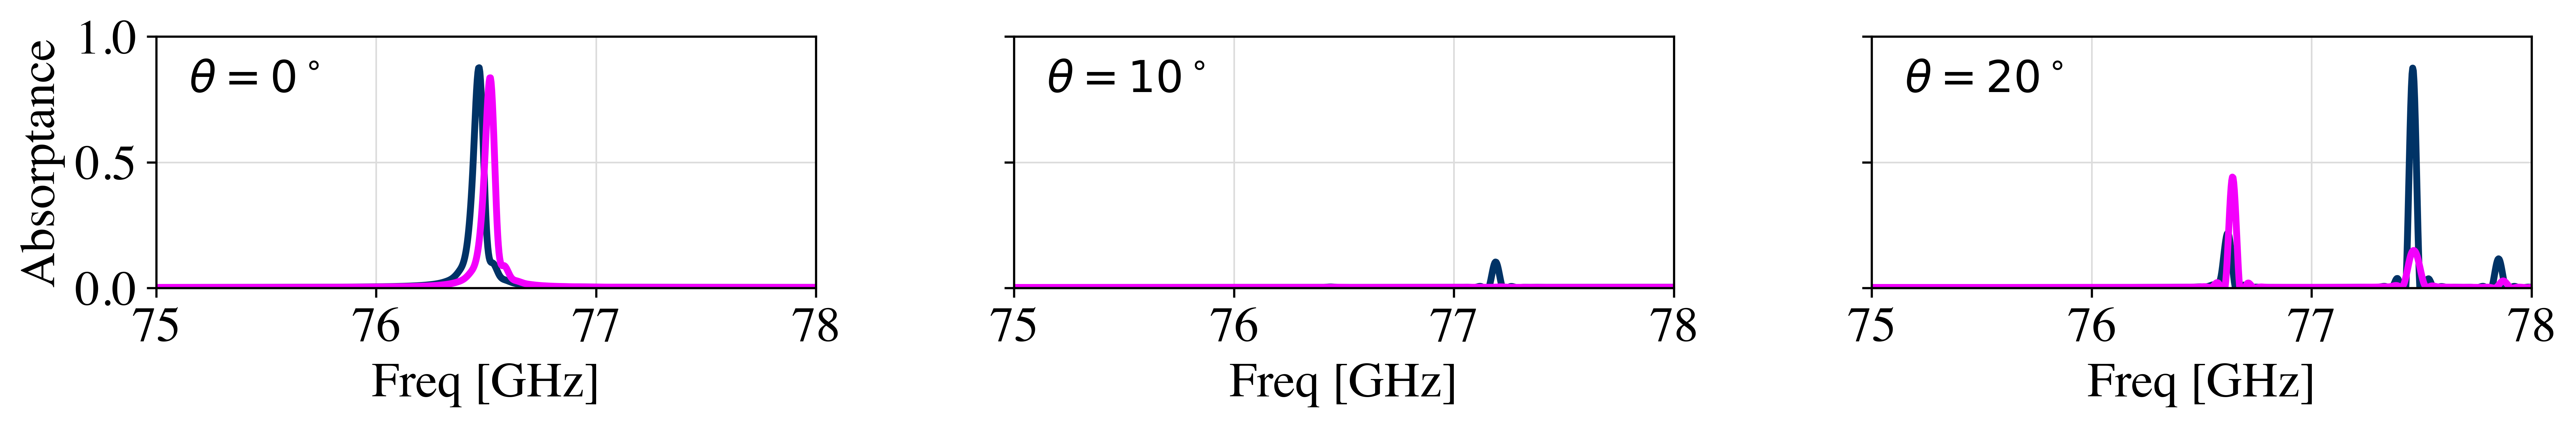

results/06c1ee2d
Angle 0° - Cosine: 0.4766655833402303, MSE: 0.027914225047412738
Angle 10° - Cosine: 0.8956085593189107, MSE: 6.054307793022655e-06
Angle 20° - Cosine: 0.05414012276109692, MSE: 0.015608608384216042


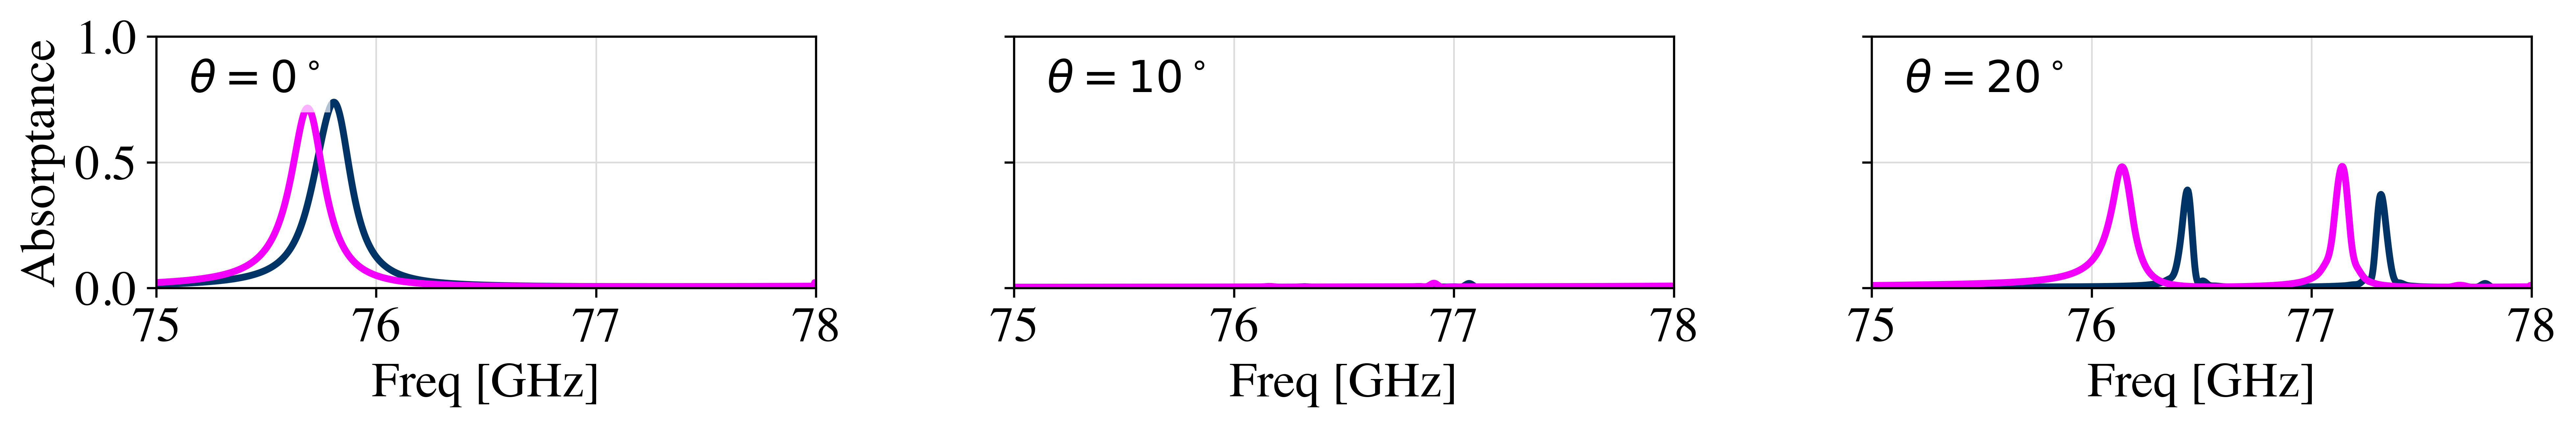

results/f6a42406
Angle 0° - Cosine: 0.2511839660448417, MSE: 0.03509610103264668
Angle 10° - Cosine: 0.5642800542112716, MSE: 0.009631285465131928
Angle 20° - Cosine: 0.7114576857350734, MSE: 0.007348539881506862


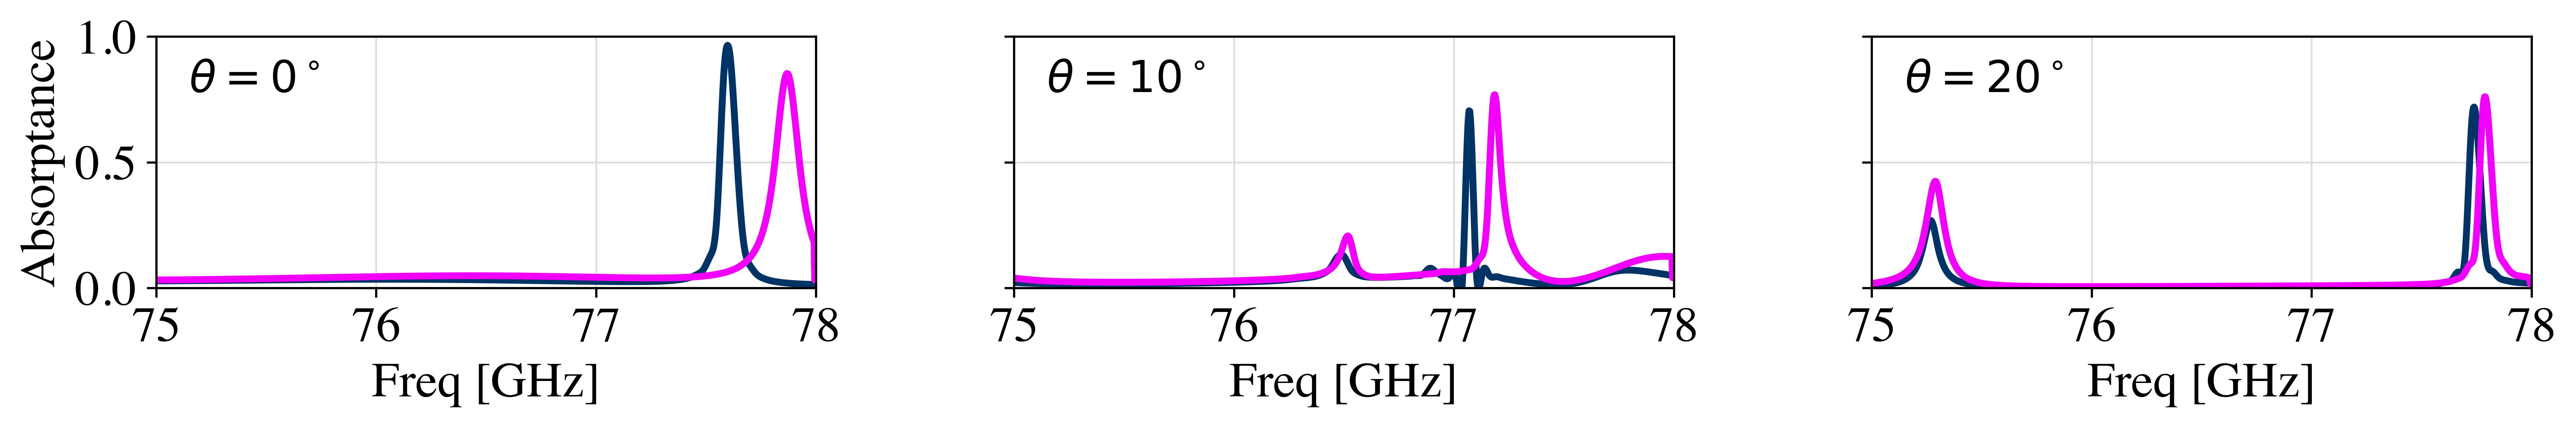

results/e03a8047
Angle 0° - Cosine: 0.42568141883952976, MSE: 0.027185867348640355
Angle 10° - Cosine: 0.6167514376006187, MSE: 0.009293784390127851
Angle 20° - Cosine: 0.3414517834265489, MSE: 0.019889241518936708


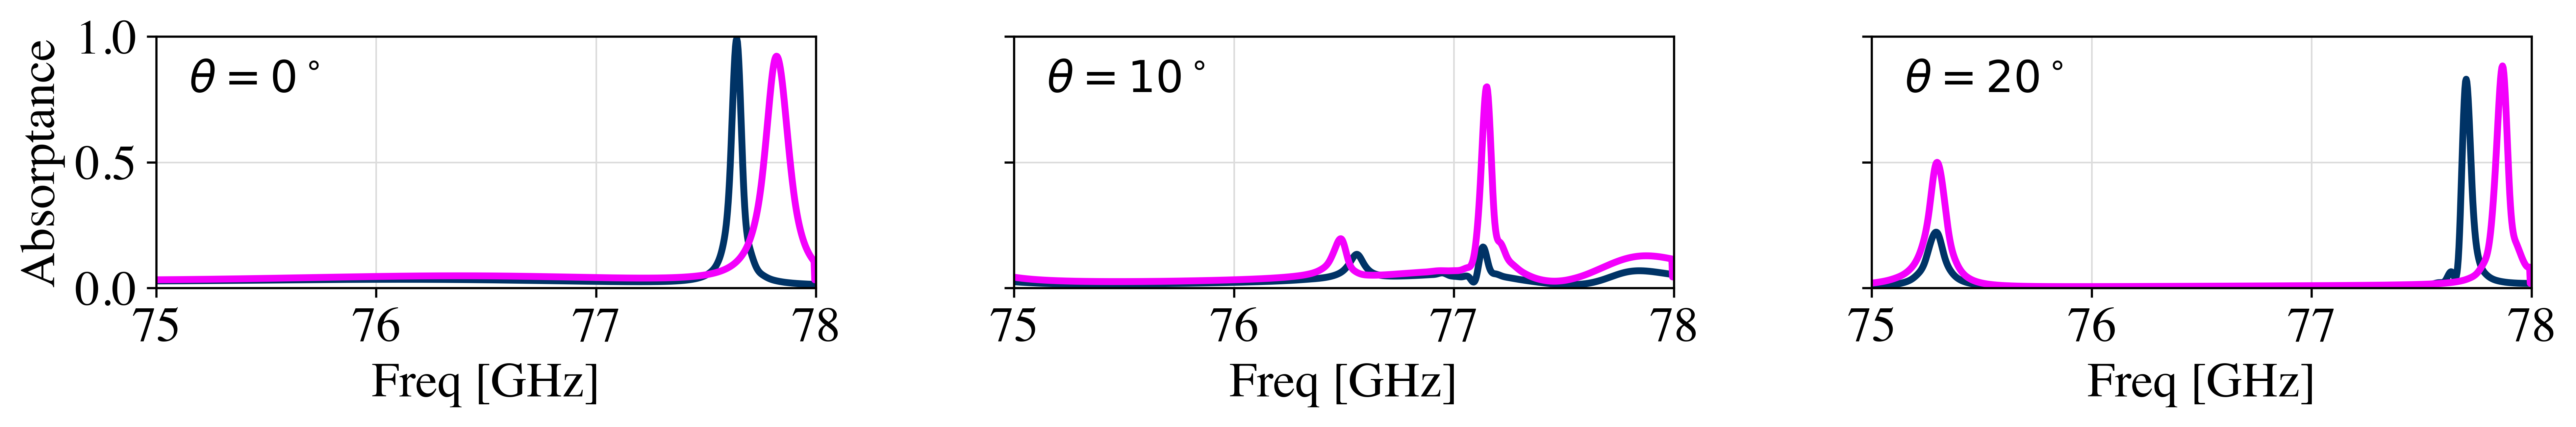

results/df12942b
Angle 0° - Cosine: 0.11758954964102514, MSE: 0.032827958364556445
Angle 10° - Cosine: 0.9758702156114236, MSE: 6.563974848895637e-07
Angle 20° - Cosine: 0.3859413081648595, MSE: 0.006992351042877744


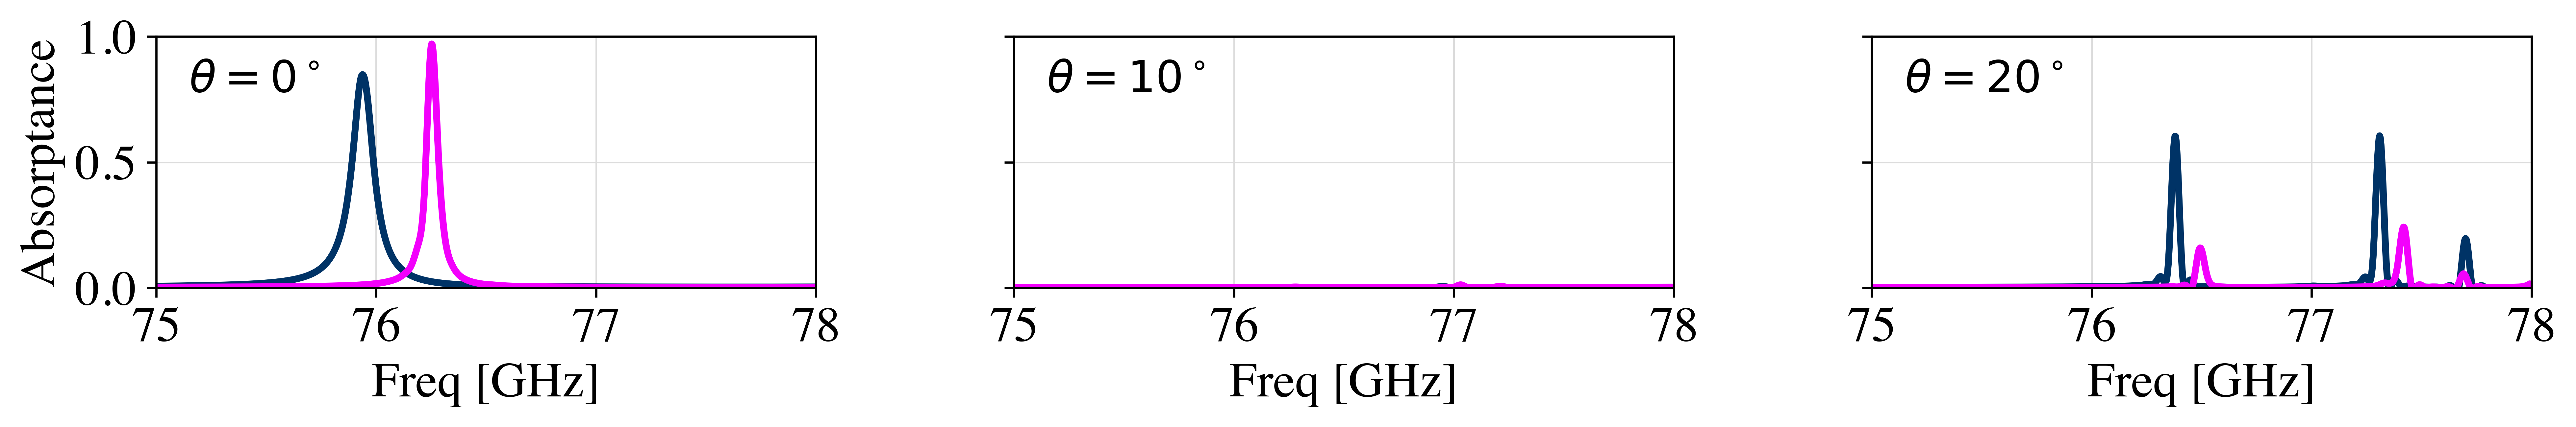

results/3a865e97
Angle 0° - Cosine: 0.11995639190675787, MSE: 0.0264336916892875
Angle 10° - Cosine: 0.6099571468155386, MSE: 0.015950343600900075
Angle 20° - Cosine: 0.1381651520887032, MSE: 0.022642408302441245


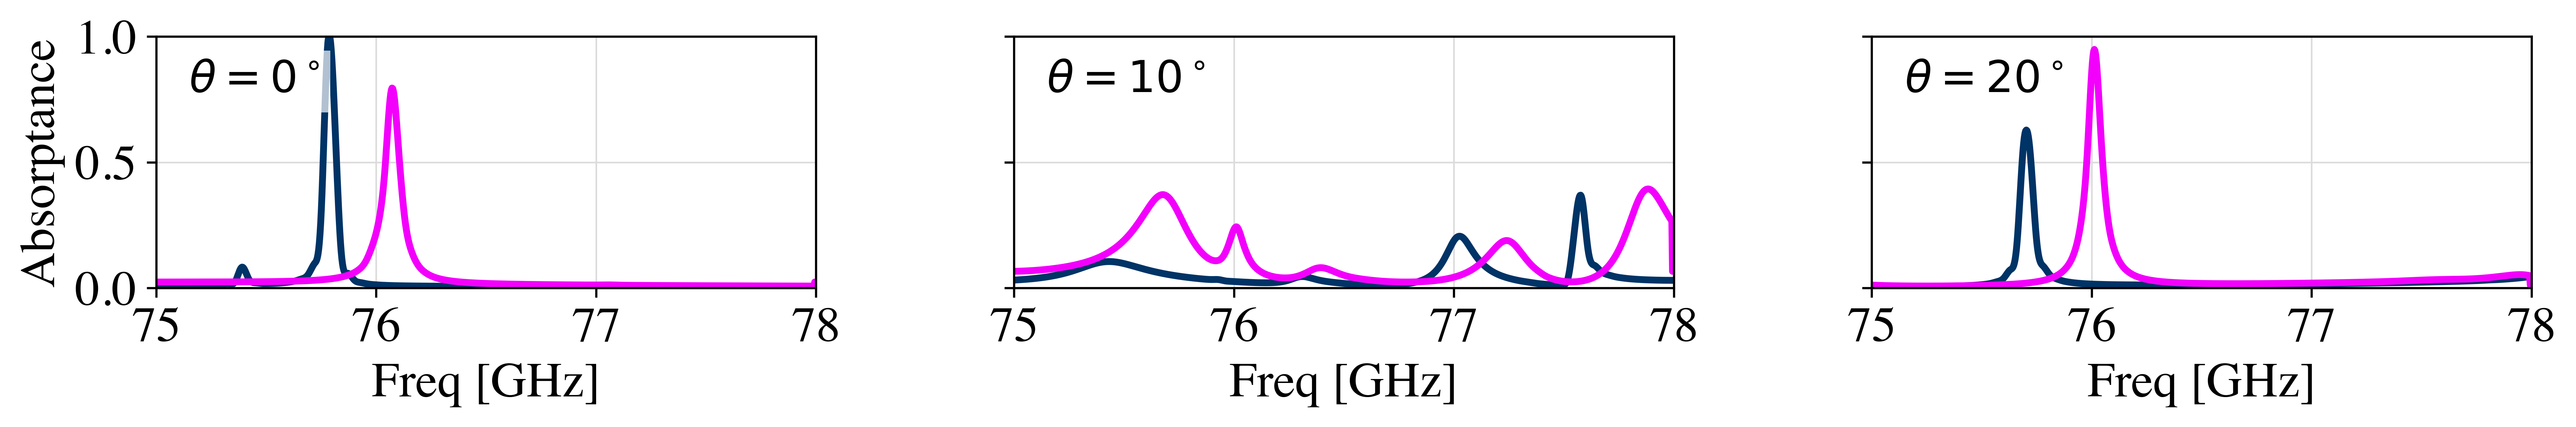

results/8c3f0b86
Angle 0° - Cosine: 0.9037578699337547, MSE: 0.012800036457218132
Angle 10° - Cosine: 0.7053805324294692, MSE: 0.0066701811432530725
Angle 20° - Cosine: 0.5352258402453296, MSE: 0.015486569892502343


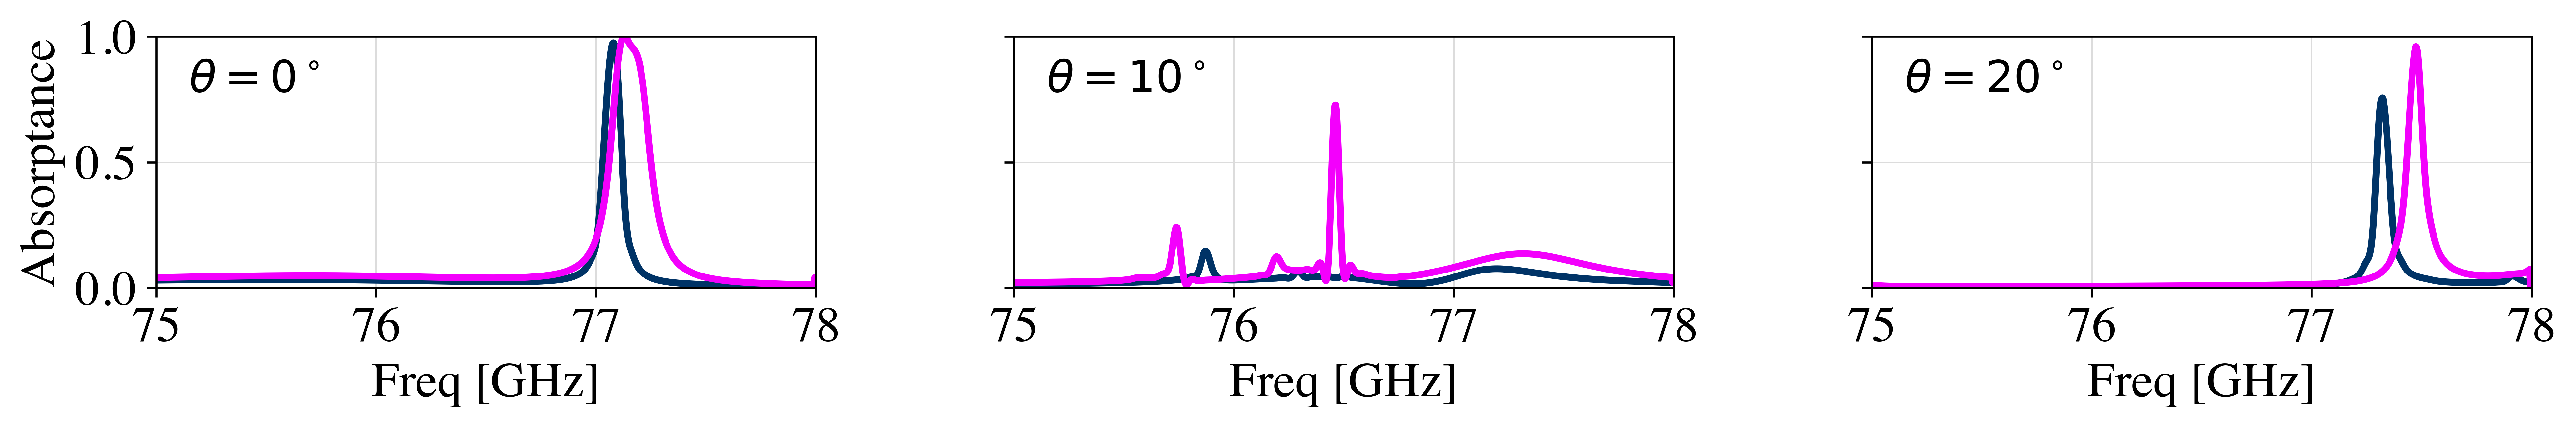

results/e3bfbedf
Angle 0° - Cosine: 0.8822227244206079, MSE: 0.0037852361238026573
Angle 10° - Cosine: 0.33099414903526025, MSE: 4.763605870128754e-05
Angle 20° - Cosine: 0.09147209362560053, MSE: 0.005774404360554776


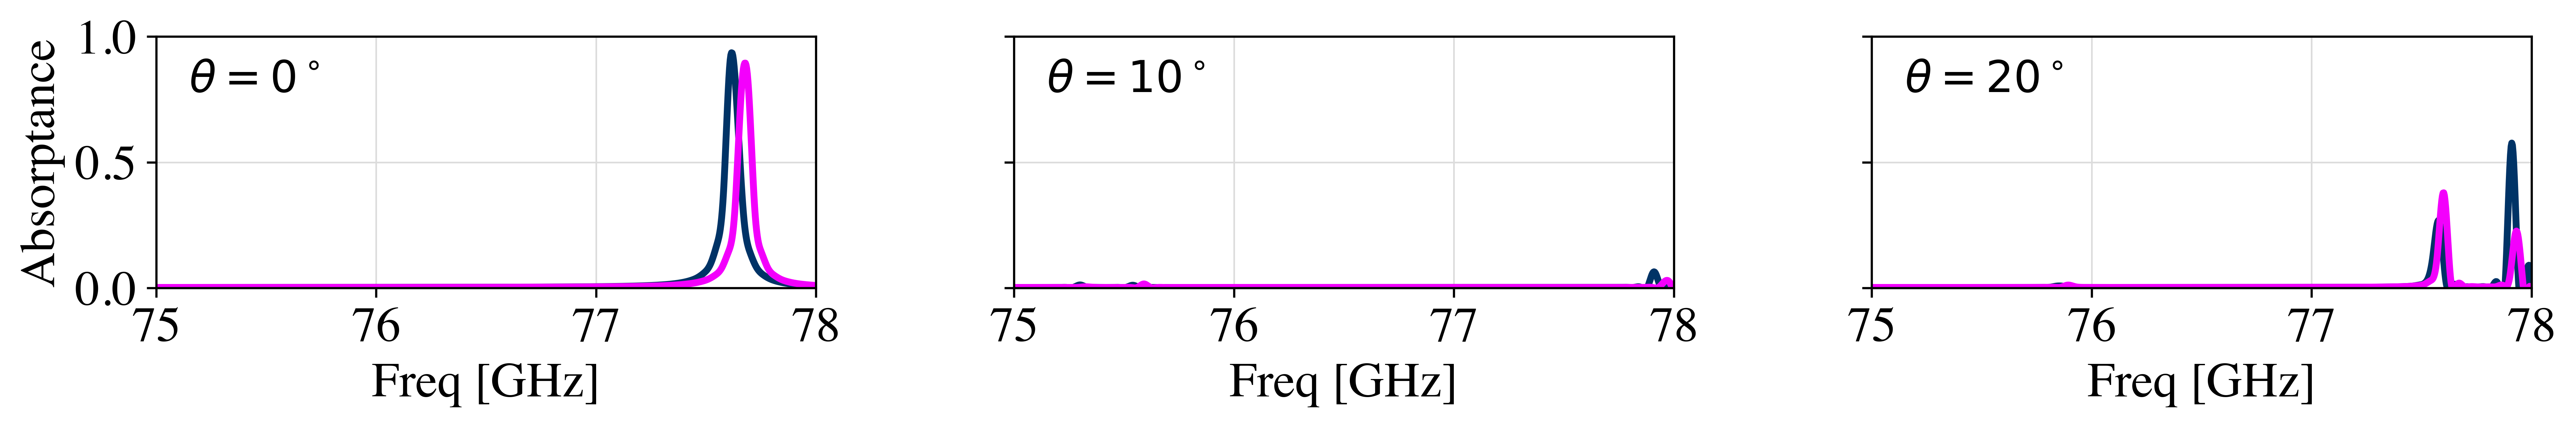

results/a3d6d65e
Angle 0° - Cosine: 0.620875791717604, MSE: 0.014052914421262839
Angle 10° - Cosine: 0.16603818212261692, MSE: 0.0009695354486174306
Angle 20° - Cosine: 0.0777706352893135, MSE: 0.014024378717968973


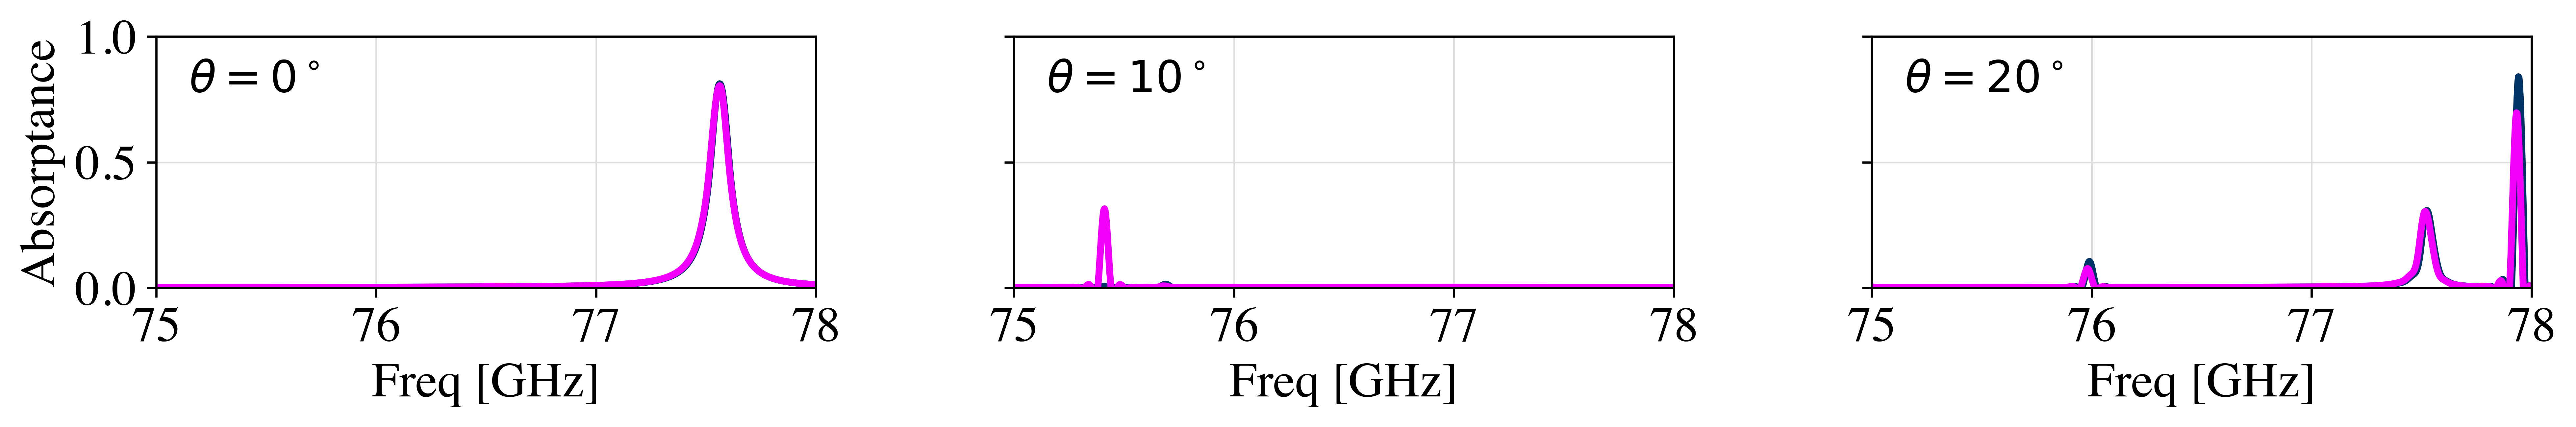

results/4e4150e1
Angle 0° - Cosine: 0.23384006968117668, MSE: 0.019977735799535913
Angle 10° - Cosine: 0.7187626658281823, MSE: 0.02357515986288426
Angle 20° - Cosine: 0.2408324497479019, MSE: 0.021549381030019188


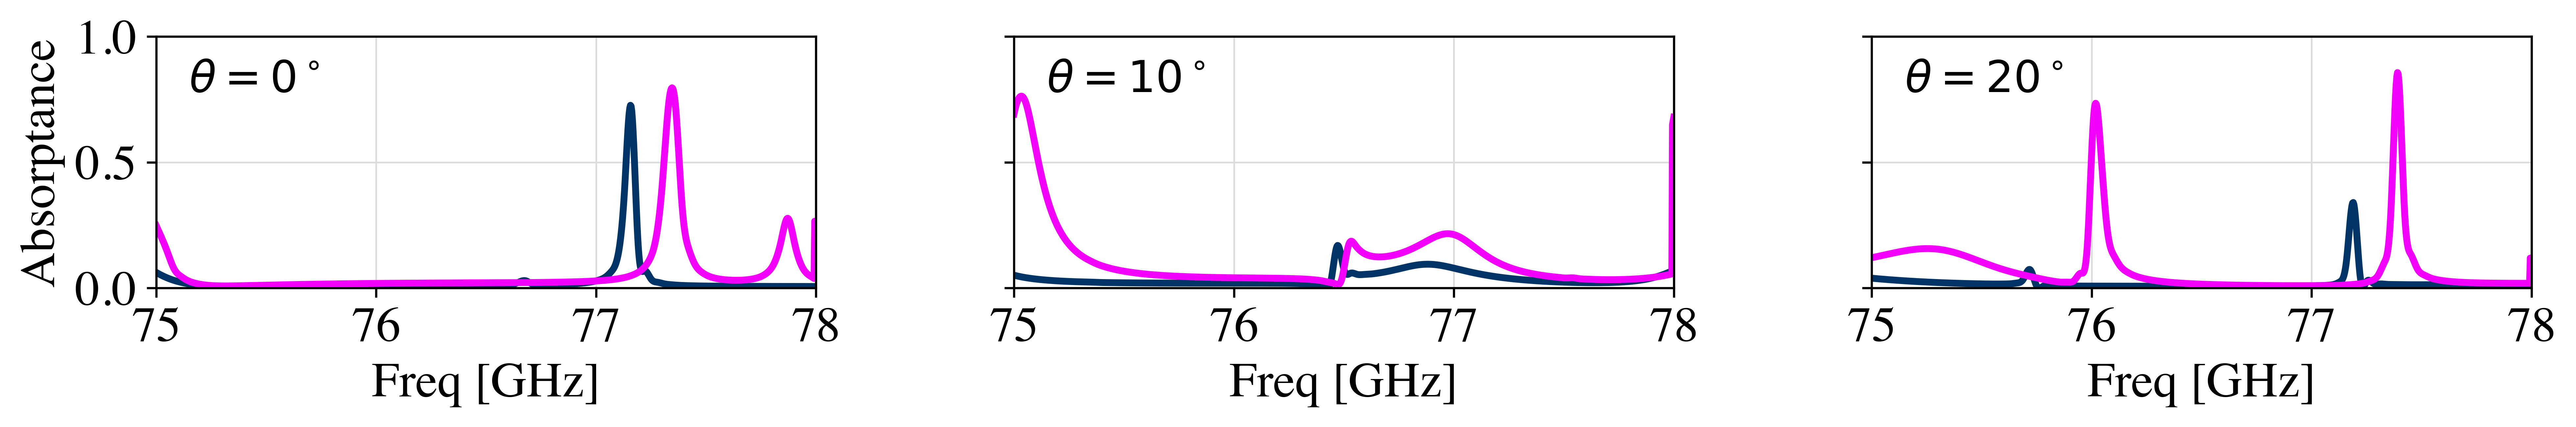

results/27a91774
Angle 0° - Cosine: 0.9401262422407671, MSE: 0.0027877116000357156
Angle 10° - Cosine: 0.11134934382958336, MSE: 0.0008816537658485809
Angle 20° - Cosine: 0.036418040594607105, MSE: 0.01723095492166776


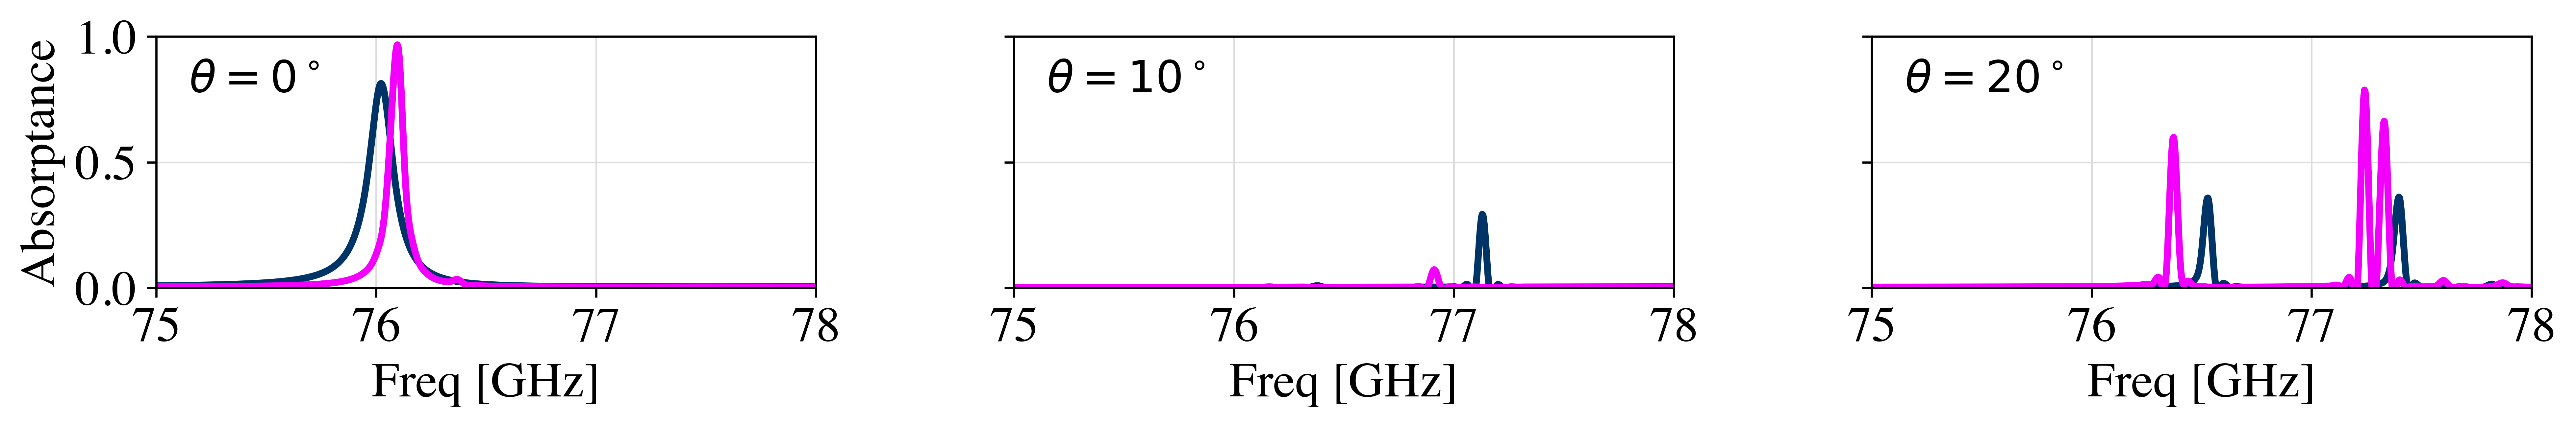

results/bdc06d34
Angle 0° - Cosine: 0.5991803829751208, MSE: 0.019113803337937357
Angle 10° - Cosine: 0.230816126467131, MSE: 0.0002882910655502601
Angle 20° - Cosine: 0.11568881468910859, MSE: 0.007384486638307642


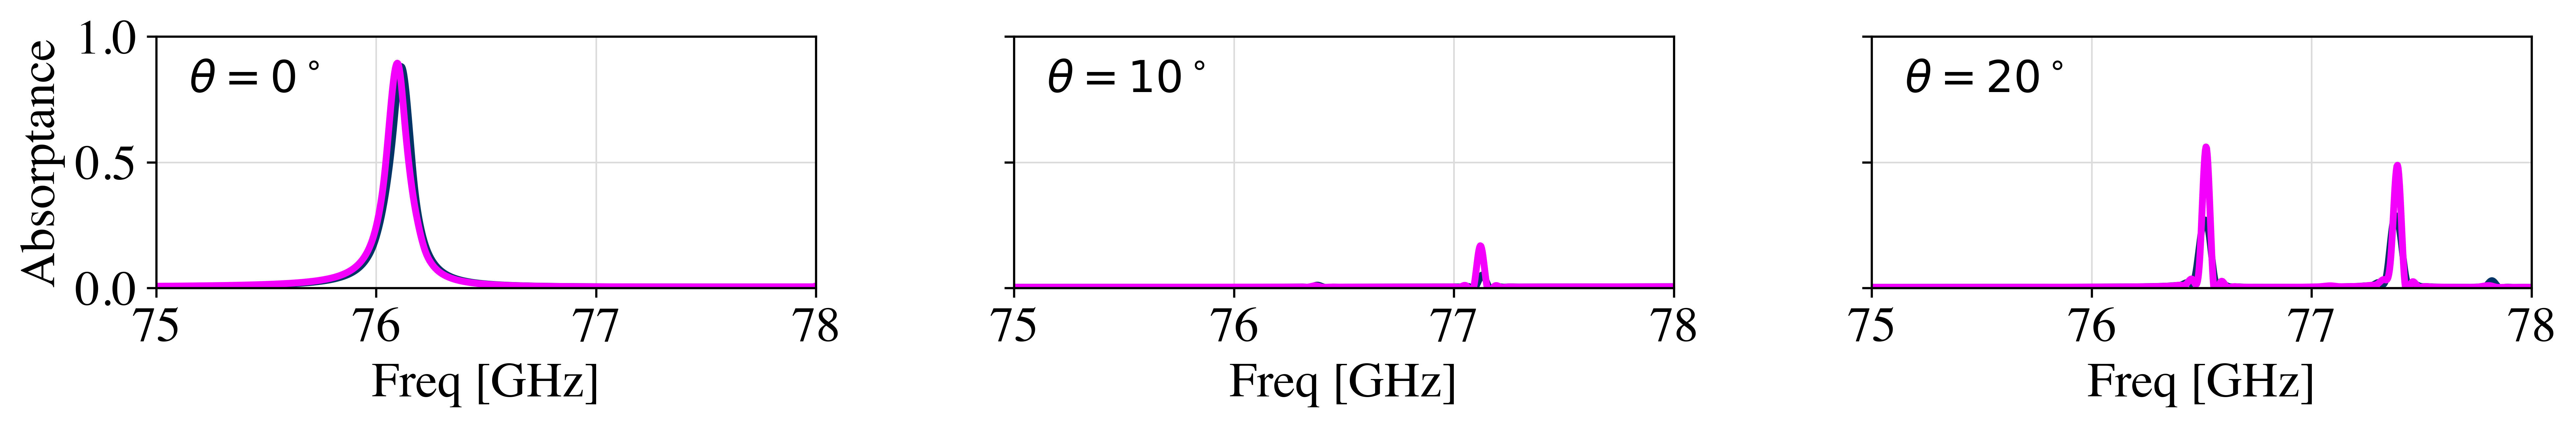

In [23]:
import glob
import pandas
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
from sklearn.metrics import mean_squared_error
from numpy import dot
from numpy.linalg import norm

for path in glob.glob('results/*'):
    print(path)

    angles = [0, 10, 20]  # Select three angles
    line_styles = ['-', '-', '-']  # Adjusted for three angles
    blues = ['#003366', '#003366', '#003366']  # Colors for Reference TE
    reds = ['#F300FC', '#F300FC', '#F300FC']  # Colors for Generated TM

    # Create a figure with three subplots in a row
    fig, axs = plt.subplots(1, 3, figsize=(13, 2.3), dpi=600)

    for idx, angle in enumerate(angles):
        csvFileRef = pandas.read_csv(path + '/AbsorptionRef_angle.csv')
        csvFileGen = pandas.read_csv(path + '/AbsorptionGen_angle.csv')

        filtered = csvFileRef[csvFileRef['angle [deg]'] == angle]
        filteredGen = csvFileGen[csvFileGen['angle [deg]'] == angle]

        minFreq = int(list(filtered["Freq [GHz]"])[0])
        maxFreq = int(list(filtered["Freq [GHz]"])[-1])

        # Reference TE
        Freq = filtered["Freq [GHz]"]
        X_Y_Spline = interp1d(filtered["Freq [GHz]"], filtered["AbsorbanceTE []"], kind='cubic')
        X_ = np.linspace(filtered["Freq [GHz]"].min(), filtered["Freq [GHz]"].max(), 1000)
        Y_ = X_Y_Spline(X_)

        # Generated TM
        X_Y_Spline = interp1d(Freq, filteredGen["AbsorbanceTE []"], kind='cubic')
        X_gen = np.linspace(Freq.min(), Freq.max(), 1000)
        Y_gen = X_Y_Spline(X_)

        Y_gen = np.roll(Y_gen, -3) 

        ax = axs[idx]
        ax.plot(X_, Y_, linestyle=line_styles[idx], label='Reference TE', linewidth=2.5, color=blues[idx])
        ax.plot(X_gen, Y_gen, linestyle=line_styles[idx], label='Generated TM', linewidth=2.5, color=reds[idx])

        ax.set_ylim(0, 1.0)
        ax.set_xlim(minFreq, maxFreq)
        ax.set_xticks([75, 76, 77, 78])

        # Set labels
        if idx == 0:  # Only leftmost plot
            ax.set_ylabel("Absorptance")
        else:
            ax.set_yticklabels([])

        ax.set_xlabel("Freq [GHz]")

        # Add angle annotation
        ax.text(0.05, 0.90, rf'$\theta={angle}^\circ$', transform=ax.transAxes, fontsize=16,
                verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

        ax.grid(which='major', axis='both', linestyle='-', color='#DCDCDC', linewidth=0.6)

        # Calculate metrics
        abs_ref = np.roll(filtered["AbsorbanceTE []"], 0) 
        abs_gen = np.roll(filteredGen["AbsorbanceTE []"], -3)
        
        mse = mean_squared_error(abs_ref, abs_gen )
        cos_sim = dot(abs_ref, abs_gen) / (
                    norm(abs_ref) * norm(abs_gen))
        print(f"Angle {angle}° - Cosine: {cos_sim}, MSE: {mse}")

    # Add a single legend for the entire figure
    #fig.legend(['Reference TE', 'Generated TM'], loc='upper center', ncol=2, fontsize=12)

    plt.tight_layout(pad=0.3)
    plt.subplots_adjust(wspace=0.3, top=0.85)  # Adjust spacing and make room for legend

    # Save the figure
    plt.savefig(path + '/results_three_angles_pol0.png', transparent=False, bbox_inches='tight')
    plt.show()

results/b84477c5
Angle 0° - Cosine: 0.12538472354879965, MSE: 0.028429217314934207
Angle 10° - Cosine: 0.16166877013468567, MSE: 0.00034223994914477063
Angle 20° - Cosine: 0.2931643225098431, MSE: 0.011734929271180021


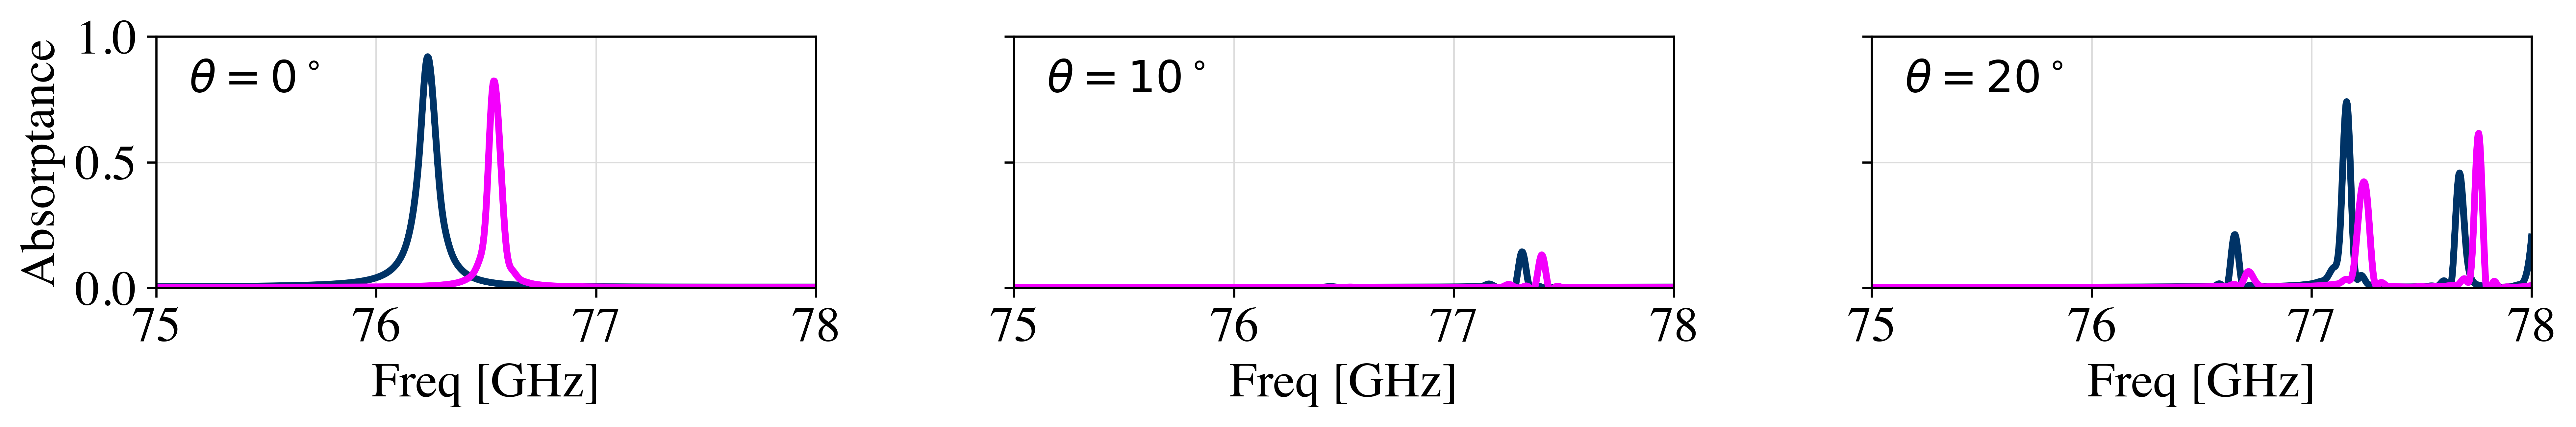

results/0a6dbd3a
Angle 0° - Cosine: 0.37400523206594843, MSE: 0.012896672859533812
Angle 10° - Cosine: 0.27896808776253473, MSE: 0.00012321817916262045
Angle 20° - Cosine: 0.04127414423262979, MSE: 0.021659684085745923


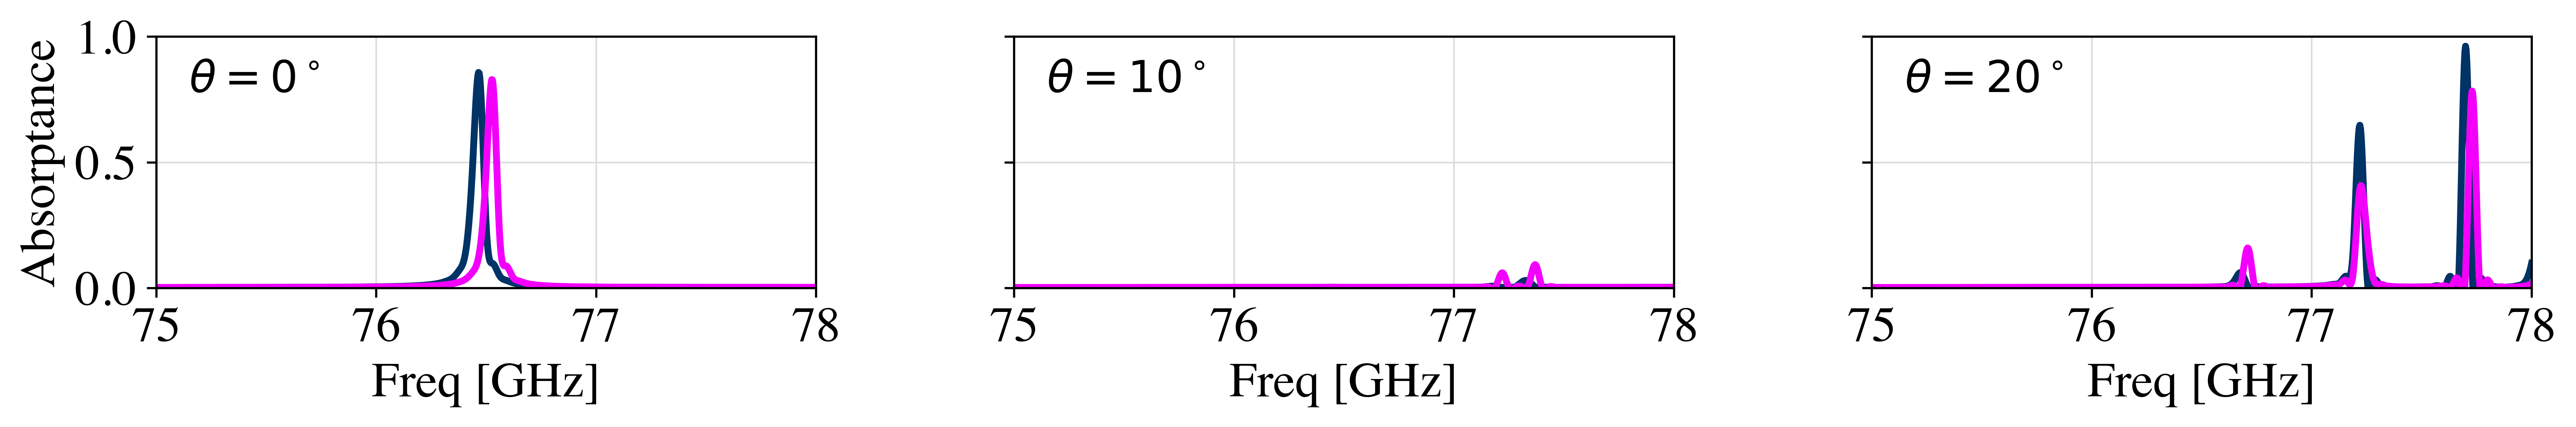

results/06c1ee2d
Angle 0° - Cosine: 0.6000934122978193, MSE: 0.021653588239053282
Angle 10° - Cosine: 0.15447120337723724, MSE: 0.0005738208707813892
Angle 20° - Cosine: 0.262147838341448, MSE: 0.03340219621034353


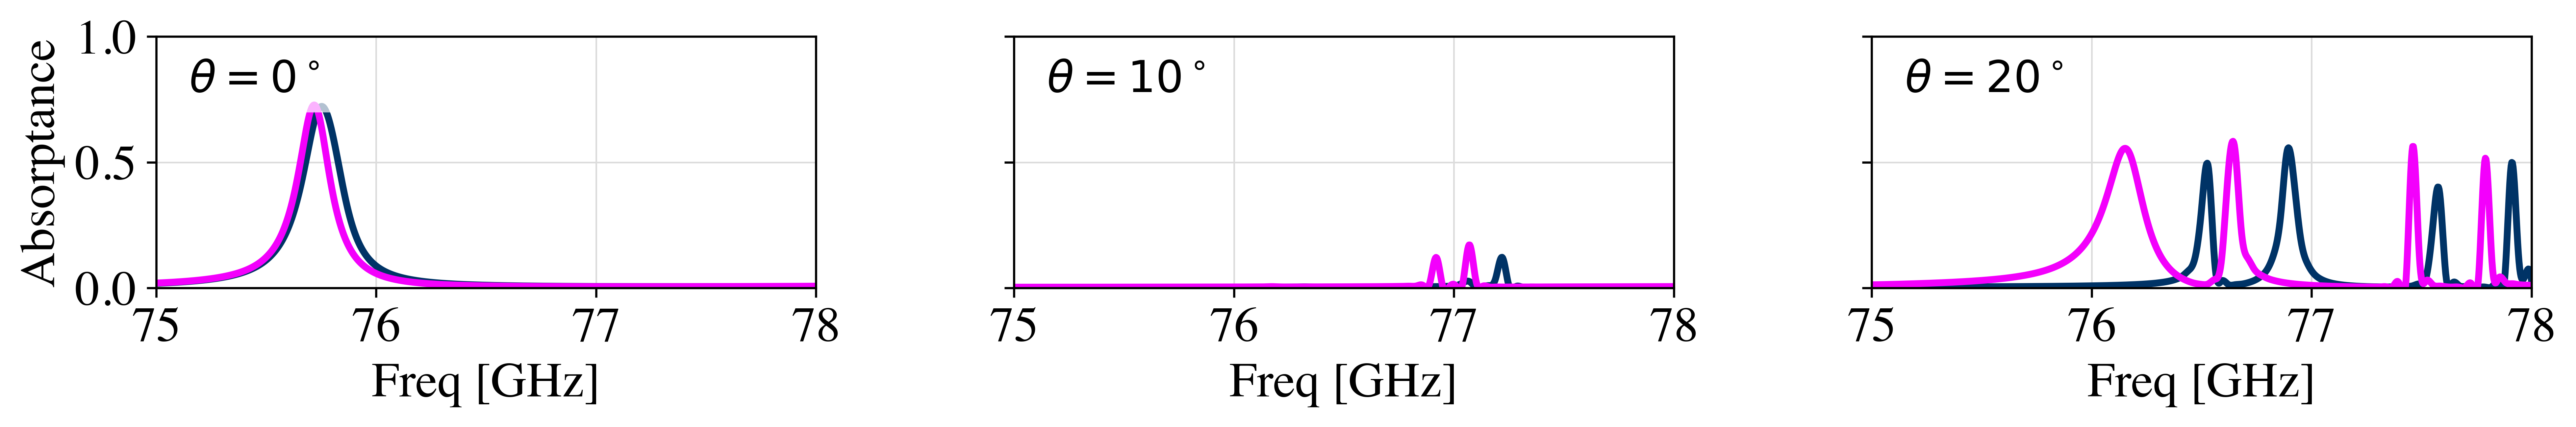

results/f6a42406
Angle 0° - Cosine: 0.3146941198556456, MSE: 0.03289755993920094
Angle 10° - Cosine: 0.8210105320151381, MSE: 0.002872609550016663
Angle 20° - Cosine: 0.2176022439884629, MSE: 0.002708735709520891


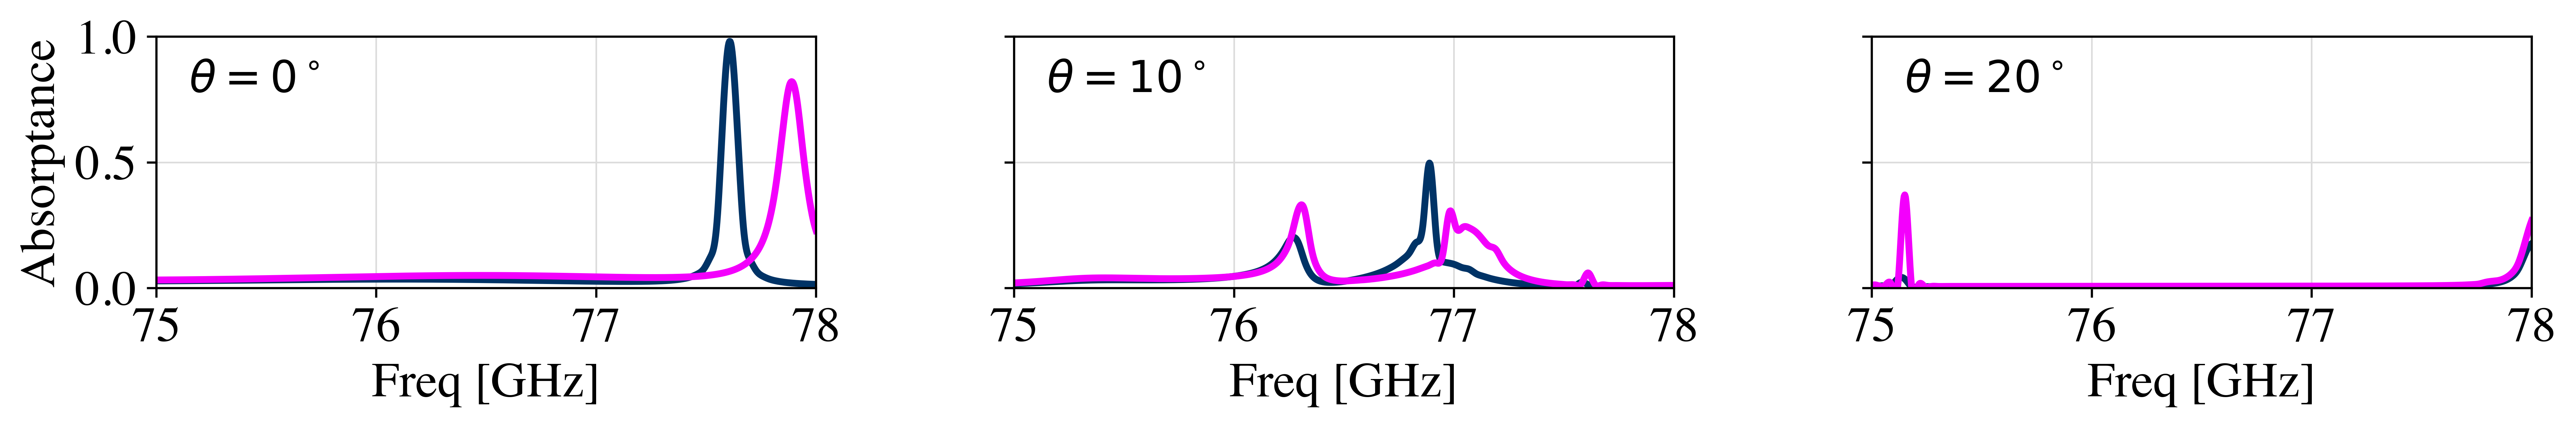

results/e03a8047
Angle 0° - Cosine: 0.5331950401824704, MSE: 0.022770887803950136
Angle 10° - Cosine: 0.7678955385446313, MSE: 0.0035413802291917305
Angle 20° - Cosine: 0.3066095892603474, MSE: 0.0026788838246721686


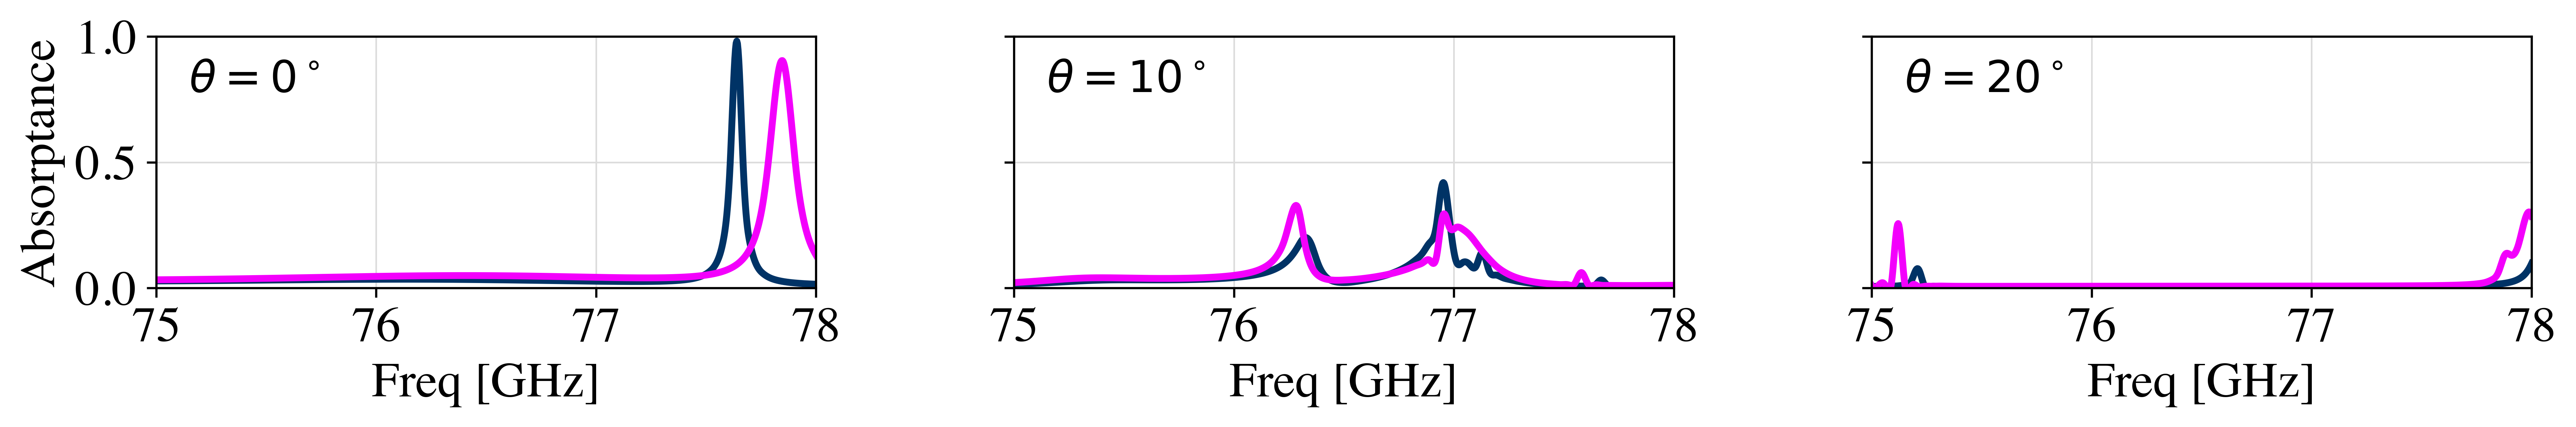

results/df12942b
Angle 0° - Cosine: 0.22024751958687191, MSE: 0.021142007877278143
Angle 10° - Cosine: 0.23806830967577597, MSE: 0.0005690708714778421
Angle 20° - Cosine: 0.16634688064317474, MSE: 0.013460381483524426


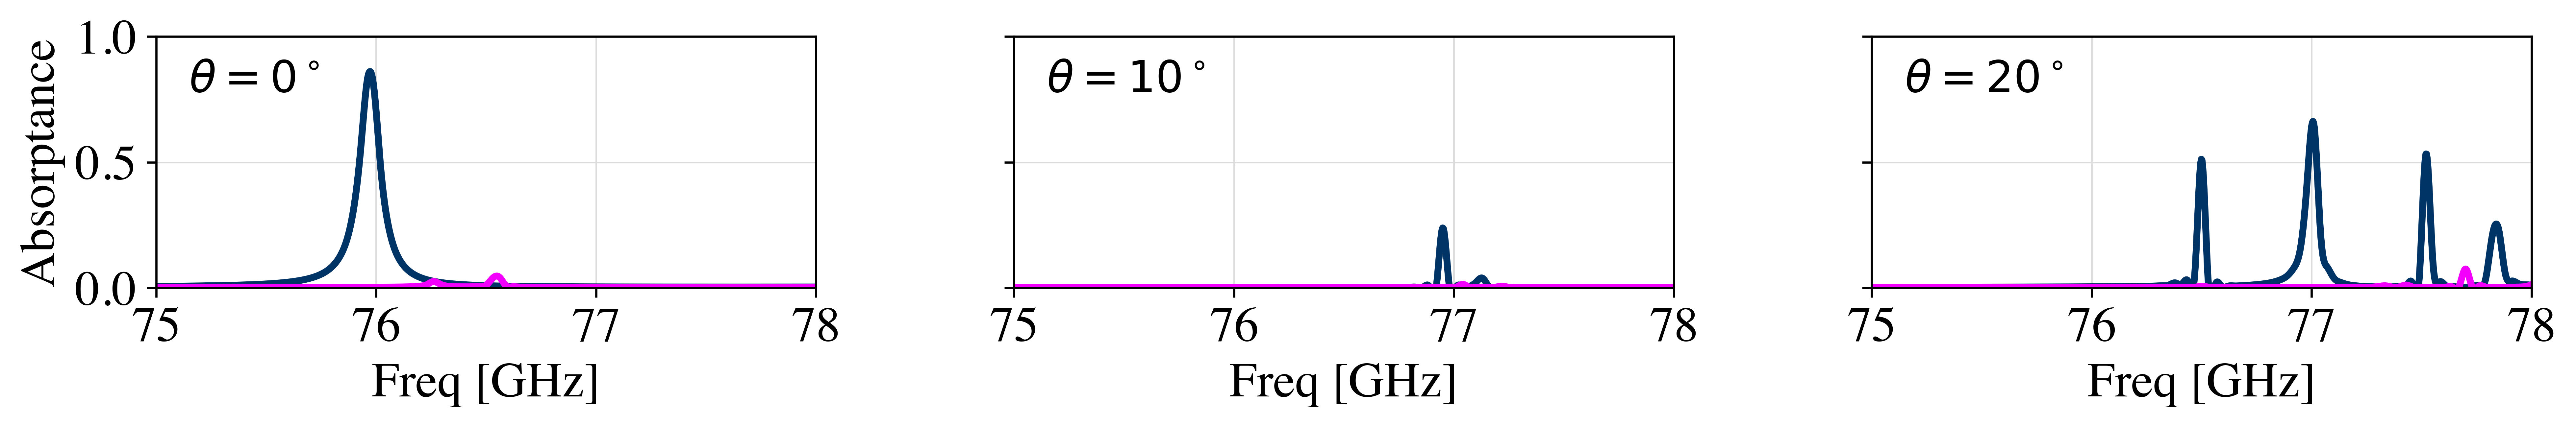

results/3a865e97
Angle 0° - Cosine: 0.3062802391203773, MSE: 0.019717167724105908
Angle 10° - Cosine: 0.7472909673344665, MSE: 0.005333136083326023
Angle 20° - Cosine: 0.7843073169152647, MSE: 0.003256377704401801


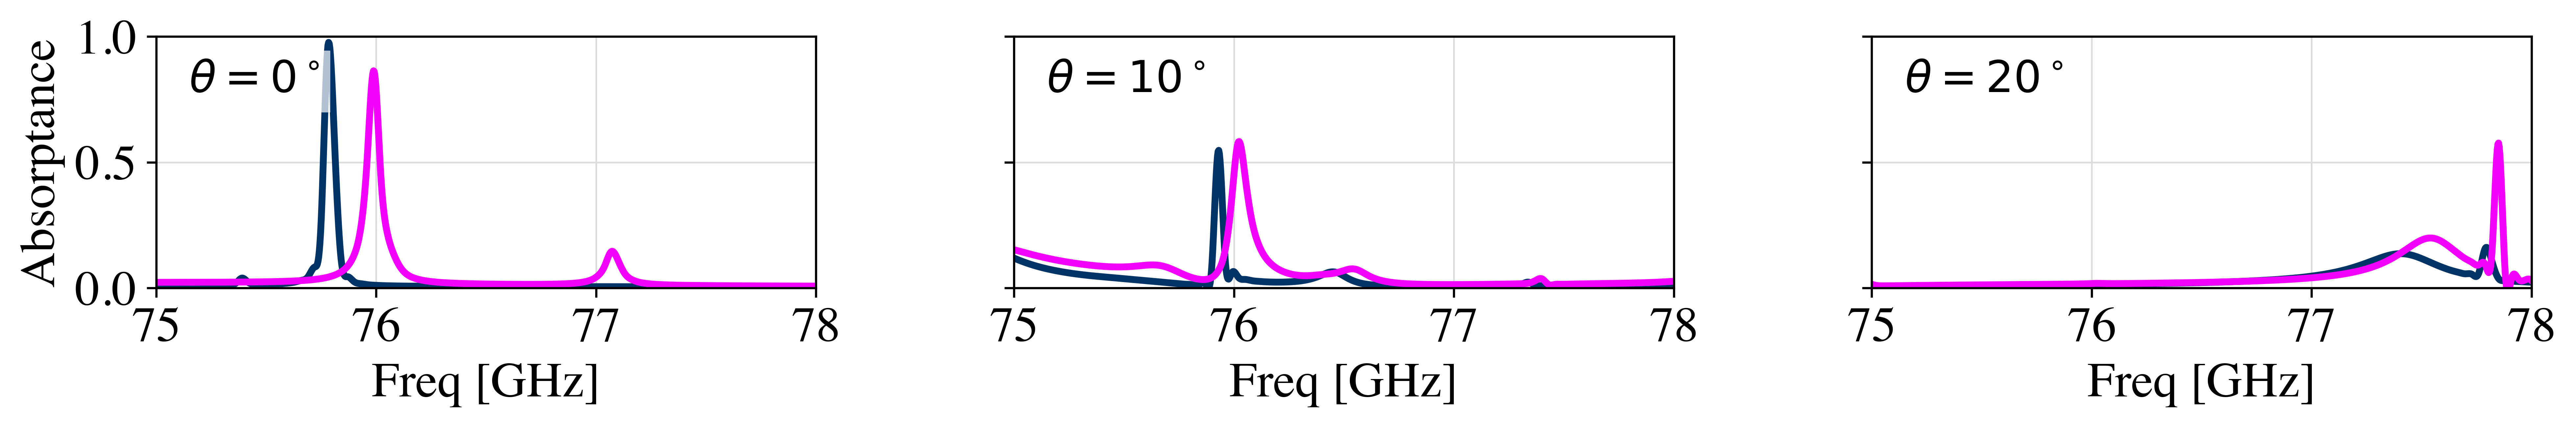

results/8c3f0b86
Angle 0° - Cosine: 0.9141412708297058, MSE: 0.011184964583108213
Angle 10° - Cosine: 0.6605533810497443, MSE: 0.009955455413634264
Angle 20° - Cosine: 0.21071525654743253, MSE: 0.005746869964464654


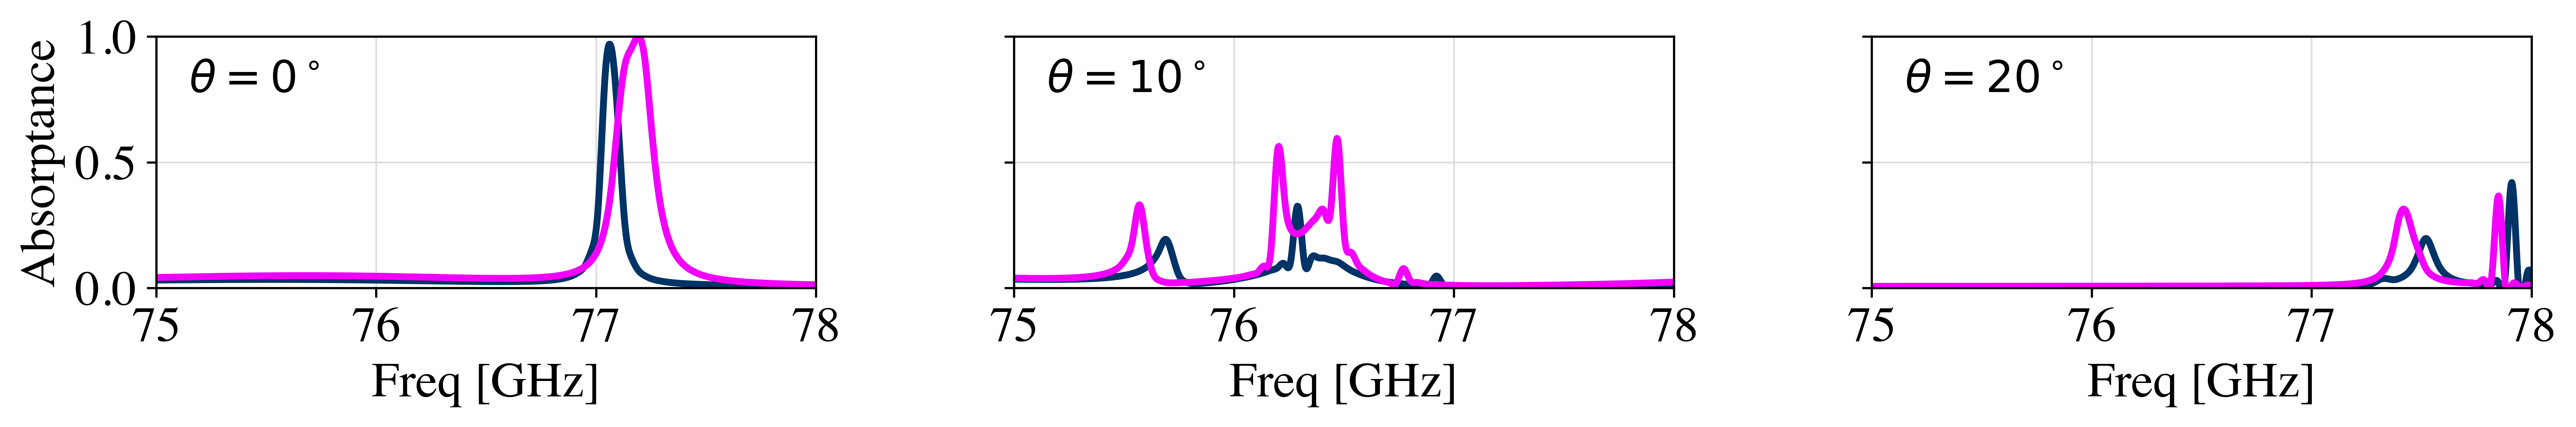

results/e3bfbedf
Angle 0° - Cosine: 0.8103918802744109, MSE: 0.006013334219067222
Angle 10° - Cosine: 0.0901731194905616, MSE: 0.004967598280147266
Angle 20° - Cosine: 0.06568144734703742, MSE: 0.010363344846100308


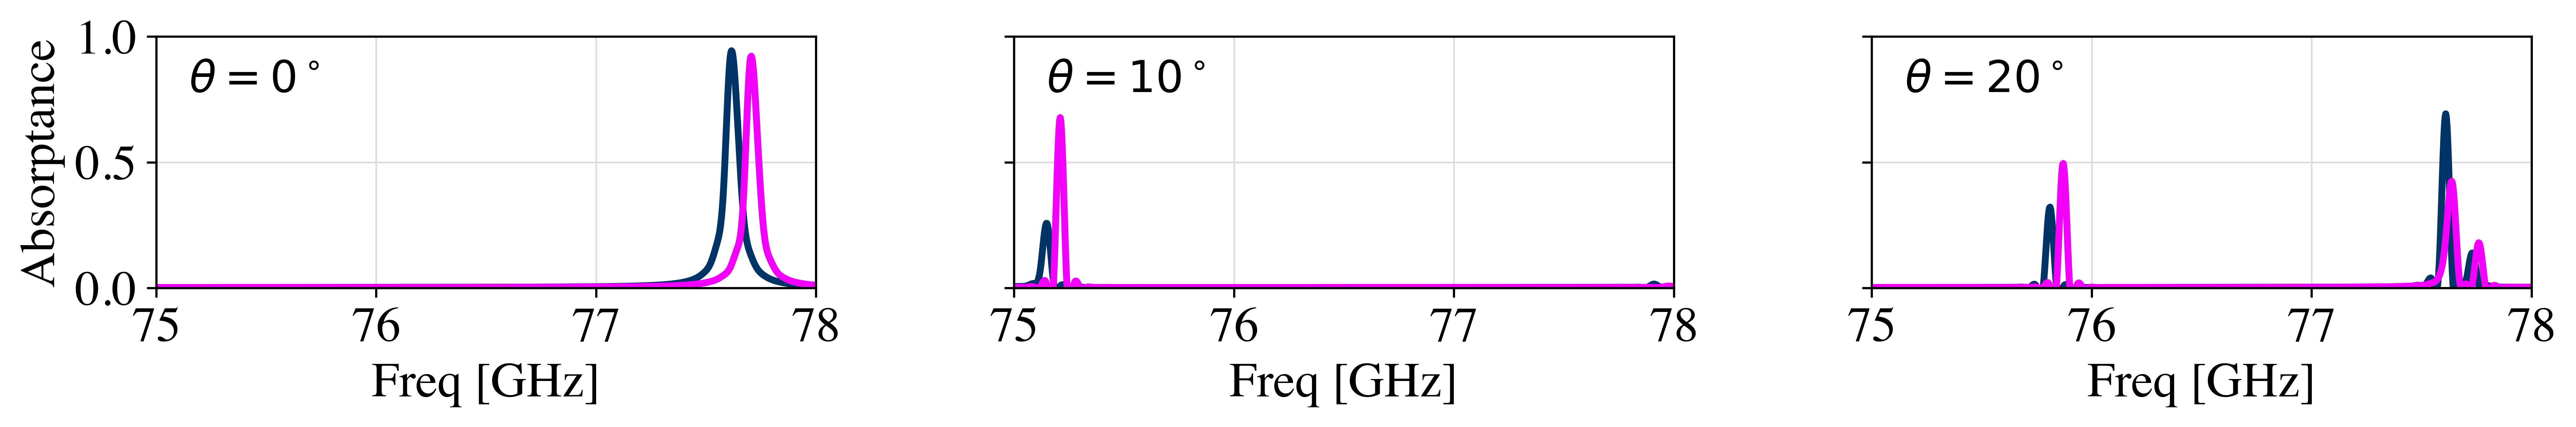

results/a3d6d65e
Angle 0° - Cosine: 0.4747872672327636, MSE: 0.019518518802964367
Angle 10° - Cosine: 0.07365822338306222, MSE: 0.0022886689075443246
Angle 20° - Cosine: 0.24707395116797698, MSE: 0.005693181917109817


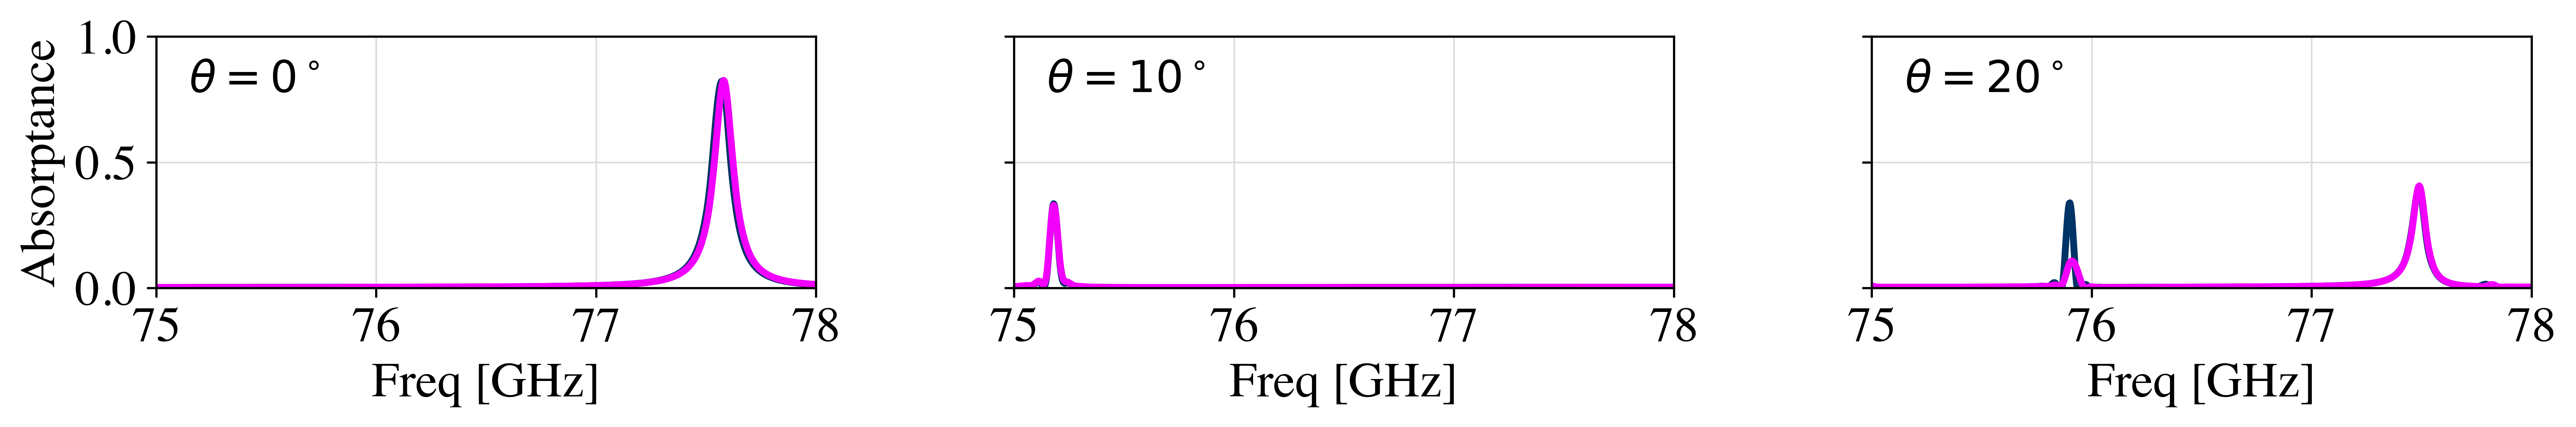

results/4e4150e1
Angle 0° - Cosine: 0.5736408752911899, MSE: 0.010951736688121131
Angle 10° - Cosine: 0.6634502682293544, MSE: 0.00818662245926128
Angle 20° - Cosine: 0.8364883535743329, MSE: 0.000741209350765472


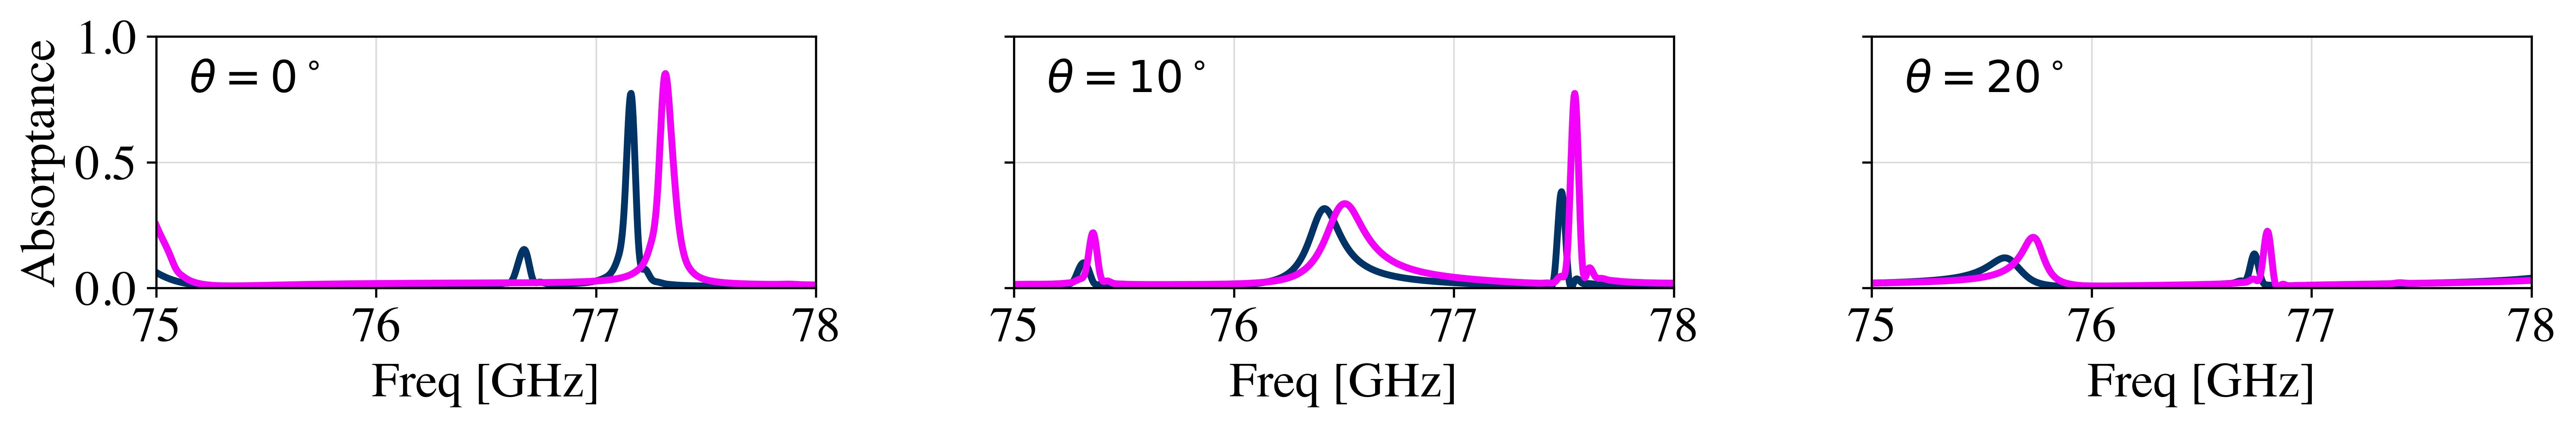

results/27a91774
Angle 0° - Cosine: 0.3069203819654526, MSE: 0.0207532212720966
Angle 10° - Cosine: 0.2351386451743097, MSE: 0.00024378101523001223
Angle 20° - Cosine: 0.07262207330209608, MSE: 0.0206338911457929


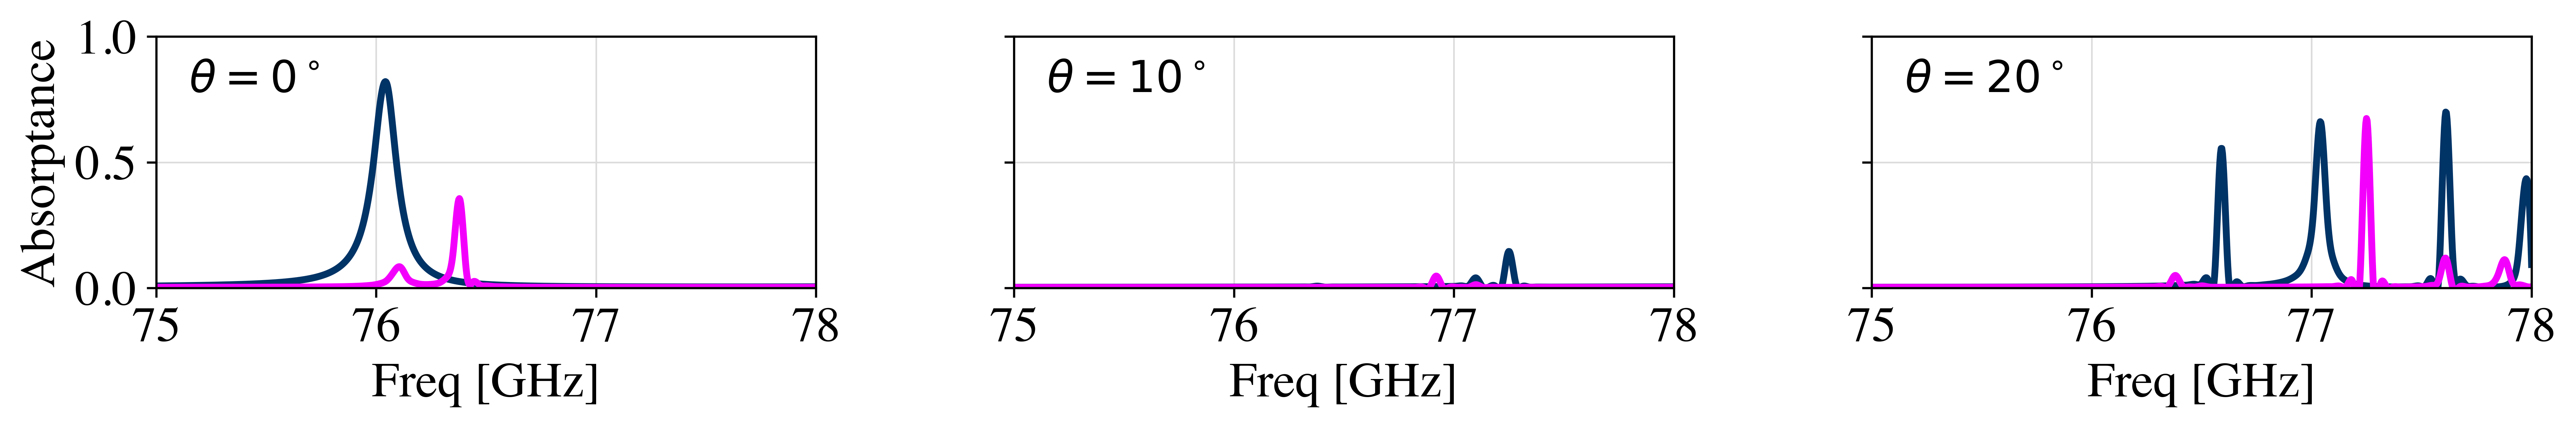

results/bdc06d34
Angle 0° - Cosine: 0.9500993326860533, MSE: 0.0024007517454084385
Angle 10° - Cosine: 0.35365450394175973, MSE: 0.00010913214735222355
Angle 20° - Cosine: 0.22444248951354603, MSE: 0.026998784248915098


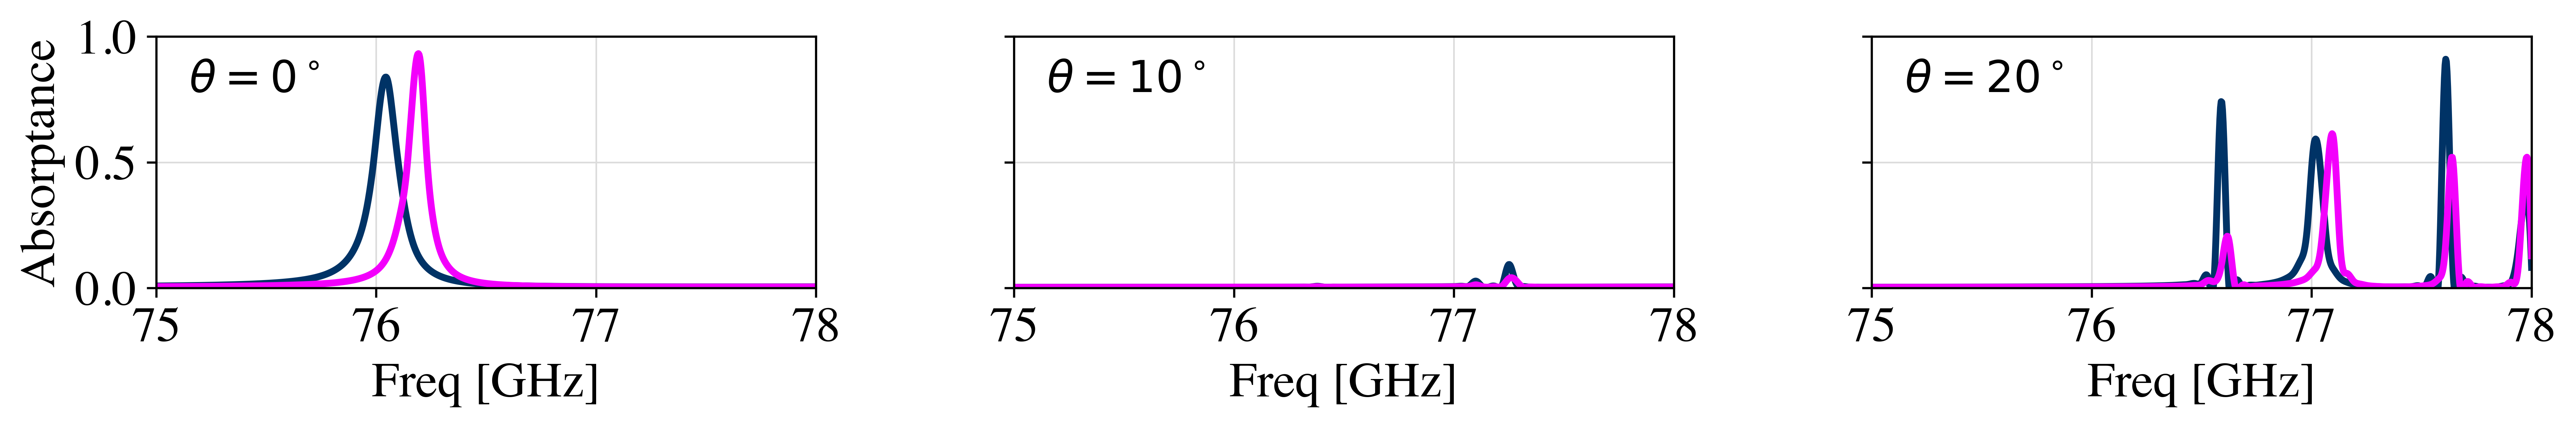

In [21]:
import glob
import pandas
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
from sklearn.metrics import mean_squared_error
from numpy import dot
from numpy.linalg import norm

for path in glob.glob('results/*'):
    print(path)

    angles = [0, 10, 20]  # Select three angles
    line_styles = ['-', '-', '-']  # Adjusted for three angles
    blues = ['#003366', '#003366', '#003366']  # Colors for Reference TE
    reds = ['#F300FC', '#F300FC', '#F300FC']  # Colors for Generated TM

    # Create a figure with three subplots in a row
    fig, axs = plt.subplots(1, 3, figsize=(13, 2.3), dpi=600)

    for idx, angle in enumerate(angles):
        csvFileRef = pandas.read_csv(path + '/AbsorptionRef_angle.csv')
        csvFileGen = pandas.read_csv(path + '/AbsorptionGen_angle.csv')

        filtered = csvFileRef[csvFileRef['angle [deg]'] == angle]
        filteredGen = csvFileGen[csvFileGen['angle [deg]'] == angle]

        minFreq = int(list(filtered["Freq [GHz]"])[0])
        maxFreq = int(list(filtered["Freq [GHz]"])[-1])

        # Reference TE
        Freq = filtered["Freq [GHz]"]
        X_Y_Spline = interp1d(filtered["Freq [GHz]"], filtered["AbsorbanceTM []"], kind='cubic')
        X_ = np.linspace(filtered["Freq [GHz]"].min(), filtered["Freq [GHz]"].max(), 1000)
        Y_ = X_Y_Spline(X_)

        # Generated TM
        X_Y_Spline = interp1d(Freq, filteredGen["AbsorbanceTM []"], kind='cubic')
        X_gen = np.linspace(Freq.min(), Freq.max(), 1000)
        Y_gen = X_Y_Spline(X_)

        ax = axs[idx]
        ax.plot(X_, Y_, linestyle=line_styles[idx], label='Reference TE', linewidth=2.5, color=blues[idx])
        ax.plot(X_gen, Y_gen, linestyle=line_styles[idx], label='Generated TE', linewidth=2.5, color=reds[idx])

        ax.set_ylim(0, 1.0)
        ax.set_xlim(minFreq, maxFreq)
        ax.set_xticks([75, 76, 77, 78])

        # Set labels
        if idx == 0:  # Only leftmost plot
            ax.set_ylabel("Absorptance")
        else:
            ax.set_yticklabels([])

        ax.set_xlabel("Freq [GHz]")

        # Add angle annotation
        ax.text(0.05, 0.90, rf'$\theta={angle}^\circ$', transform=ax.transAxes, fontsize=16,
                verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

        ax.grid(which='major', axis='both', linestyle='-', color='#DCDCDC', linewidth=0.6)

        # Calculate metrics
        abs_ref = np.roll(filtered["AbsorbanceTM []"], 0) 
        abs_gen = np.roll(filteredGen["AbsorbanceTM []"], -4) 
        
        mse = mean_squared_error(abs_ref, abs_gen )
        cos_sim = dot(abs_ref, abs_gen) / (
                    norm(abs_ref) * norm(abs_gen))
        print(f"Angle {angle}° - Cosine: {cos_sim}, MSE: {mse}")

    # Add a single legend for the entire figure
    #fig.legend(['Reference TE', 'Generated TM'], loc='upper center', ncol=2, fontsize=12)

    plt.tight_layout(pad=0.3)
    plt.subplots_adjust(wspace=0.3, top=0.85)  # Adjust spacing and make room for legend

    # Save the figure
    plt.savefig(path + '/results_three_angles_pol1.png', transparent=False, bbox_inches='tight')
    plt.show()